In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('energies.csv',index_col=0)

In [3]:
diffdf = []
for basis in df['Basis Set'].unique():
    for molecule in df['Molecule'].unique():
        subset = df[(df['Basis Set'] == basis) & (df['Molecule'] == molecule)]
        subset.loc[:, 'Energy'] = subset.loc[:, 'Energy'].values - subset.loc[subset['Method'] == 'SHCI', 'Energy'].values
        diffdf.append(subset)

diffdf = pd.concat(diffdf)        

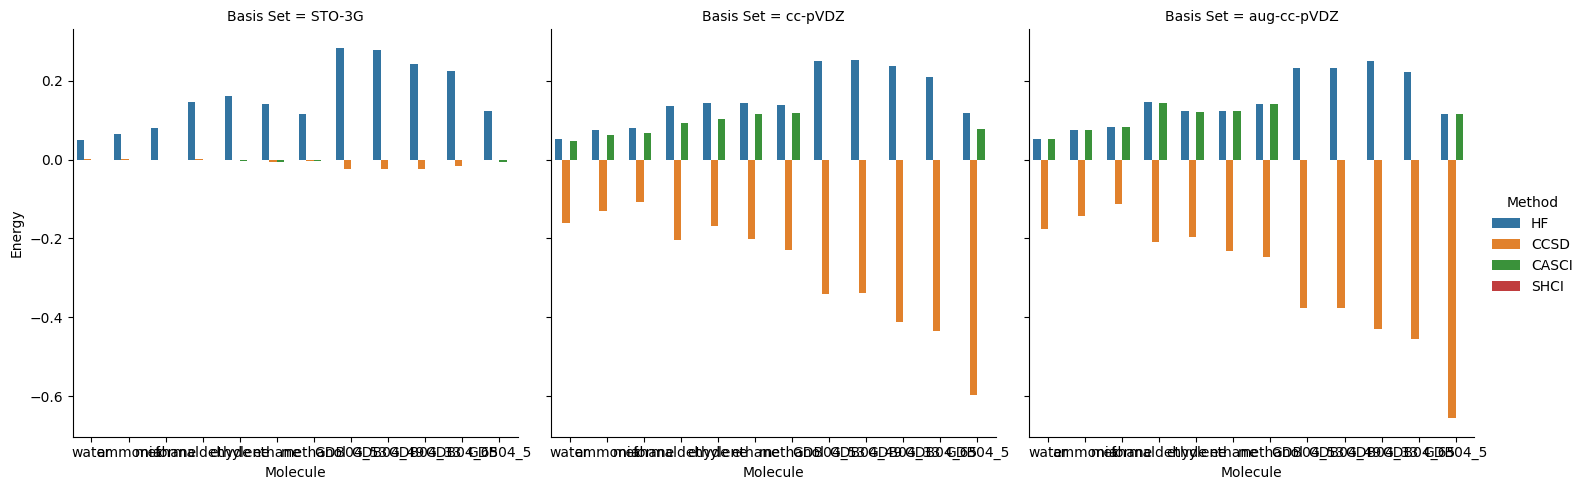

In [4]:
sns.catplot(diffdf,x='Molecule',y='Energy',hue='Method',col='Basis Set',kind='bar')